# Bước 6: Hồ sơ cụm & Chiến lược — Giá trị thực trên dữ liệu gốc

Các notebook 02–04 phân cụm trên đặc trưng đã **QuantileTransform + StandardScaler + cắt ±3σ** — không gian tốt cho khoảng cách Euclid nhưng *không đọc được* về mặt kinh doanh (một khách hàng có `AOV = 0.32` nghĩa là gì?).

Notebook này ánh xạ **4 cụm retail** trở lại **đơn vị gốc, dễ diễn giải** (bảng Anh, số đơn hàng, số ngày, tỉ lệ %) tính trực tiếp trên giao dịch đã làm sạch, để chuyển mỗi phân khúc thành **chiến lược hành động cụ thể**.


## Mục tiêu

1. Tính **KPI kinh doanh thô** cho từng khách hàng từ giao dịch gốc: LTV (doanh thu), tần suất, AOV, số SKU, số hàng/giỏ.
2. Kèm theo **đặc trưng hành vi thô** (chưa transform): Recency, MonthlyOrderRate, ReturnRate, QuarterConcentration, RepeatSKUFraction.
3. Tổng hợp theo cụm bằng **trung vị** (bền với outlier) → bảng hồ sơ.
4. Trực quan hoá: nghịch lý Pareto (dân số vs doanh thu), vân tay cụm, so sánh KPI cốt lõi.
5. Lưu hồ sơ từng khách hàng + bảng tóm tắt, và đúc kết **chiến lược cho từng cụm** dựa trên con số thực.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('../src')

from clustering_library import FeatureEngineer
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
from visual_style import CLUSTER_COLORS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
sns.set_style('whitegrid')

ROOT = Path('../').resolve()
FIG_DIR = ROOT / 'figures' / '05_profiling'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Tên phân khúc theo cụm — KHÔNG đổi thứ tự (khớp 03_modeling)
SEGMENT_NAMES = {
    0: 'Seasonal Intensives',
    1: 'High-Return Actives',
    2: 'One-Time Explorers',
    3: 'Occasional Loyalists',
}
CLUSTER_ORDER = [0, 1, 2, 3]

## 1. Tải dữ liệu gốc đã làm sạch và nhãn cụm

`cleaned_uk_data.csv` (đầu ra notebook 01) là dữ liệu giao dịch gốc; `cluster_assignments_retail_k4.csv` (đầu ra notebook 03) gán mỗi khách retail vào 1 trong 4 cụm.


In [2]:
# Đọc từ sandbox nếu có (manual run), ngược lại đọc bản canonical.
data_path     = rpath('processed/cleaned_uk_data.csv')
raw_data_path = '../data/raw/online_retail.csv'

fe = FeatureEngineer(data_path, raw_data_path=raw_data_path)
df = fe.load_data()

assignments = pd.read_csv(rpath('processed/cluster_assignments_retail_k4.csv')).set_index('CustomerID')

print(f"Giao dịch gốc : {df.shape[0]:,} dòng | {df['CustomerID'].nunique():,} khách hàng UK")
print(f"Nhãn cụm      : {len(assignments):,} khách retail trên {assignments['cluster'].nunique()} cụm")
assignments['segment'].value_counts()

Giao dịch gốc : 354,321 dòng | 3,920 khách hàng UK
Nhãn cụm      : 3,741 khách retail trên 4 cụm


segment
One-Time Explorers      1257
High-Return Actives     1107
Occasional Loyalists    1047
Seasonal Intensives      330
Name: count, dtype: int64

## 2. Tính giá trị thô cho từng khách hàng

**(a) KPI kinh doanh** — tính trực tiếp trên giao dịch gốc, đọc được ngay:

| KPI | Ý nghĩa |
|-----|---------|
| `TotalRevenue` | LTV / Monetary — tổng chi tiêu |
| `NumOrders` | Frequency — số hoá đơn phân biệt |
| `AOV` | Giá trị trung bình mỗi đơn |
| `AvgBasketItems` | Số món trung bình mỗi giỏ |
| `NumUniqueSKU` | Độ rộng danh mục đã mua |

**(b) Đặc trưng hành vi thô** — tái dùng `FeatureEngineer` để lấy 5 trục quyết định phân khúc (chưa transform, đúng đơn vị gốc): `Recency` (ngày), `MonthlyOrderRate`, `ReturnRate` (tỉ lệ huỷ hoá đơn), `QuarterConcentration`, `RepeatSKUFraction`.


In [3]:
# --- (a) KPI kinh doanh dễ diễn giải ---
g = df.groupby('CustomerID')
kpi = pd.DataFrame({
    'TotalRevenue': g['TotalPrice'].sum(),     # LTV / Monetary
    'NumOrders':    g['InvoiceNo'].nunique(),   # Frequency
    'NumUniqueSKU': g['StockCode'].nunique(),
    'TotalItems':   g['Quantity'].sum(),
})
kpi['AOV']            = kpi['TotalRevenue'] / kpi['NumOrders']
kpi['AvgBasketItems'] = kpi['TotalItems']  / kpi['NumOrders']

# --- (b) Đặc trưng hành vi THÔ (chưa transform) — tái dùng FeatureEngineer ---
fe.create_customer_features()   # điền fe.customer_feature_candidates (20 đặc trưng thô)
raw_feats = fe.customer_feature_candidates[
    ['Recency', 'MonthlyOrderRate', 'ReturnRate', 'QuarterConcentration', 'RepeatSKUFraction']
].copy()

# --- (c) Gộp KPI + đặc trưng thô + nhãn cụm (chỉ giữ khách retail đã gán cụm) ---
profiles = assignments[['cluster']].join(kpi, how='left').join(raw_feats, how='left')
profiles['segment'] = profiles['cluster'].map(SEGMENT_NAMES)

print(f"Hồ sơ khách hàng: {profiles.shape[0]:,} dòng × {profiles.shape[1]} cột")
assert profiles.drop(columns='segment').isna().sum().sum() == 0, 'Có giá trị thiếu!'
profiles.head()

Hồ sơ khách hàng: 3,741 dòng × 13 cột


,cluster,TotalRevenue,NumOrders,NumUniqueSKU,TotalItems,AOV,AvgBasketItems,Recency,MonthlyOrderRate,ReturnRate,QuarterConcentration,RepeatSKUFraction,segment
CustomerID,,,,,,,,,,,,,
12747,3,"4,196.01",11,42,1275,381.46,115.91,2,0.90,0.00,0.51,0.45,Occasional Loyalists
12748,1,"33,719.73",209,1768,25747,161.34,123.19,1,16.85,0.06,0.54,0.56,High-Return Actives
12749,1,"4,090.88",5,160,1471,818.18,294.20,4,0.72,0.38,0.46,0.23,High-Return Actives
12820,3,942.34,4,55,722,235.59,180.50,3,0.37,0.00,0.59,0.07,Occasional Loyalists
12821,2,92.72,1,6,70,92.72,70.00,214,1.00,0.00,1.00,0.00,One-Time Explorers


## 3. Bảng hồ sơ theo cụm

Dùng **trung vị** cho mỗi chỉ số (bền với outlier — vài khách VIP không kéo lệch chân dung cả cụm), kèm quy mô dân số và **đóng góp doanh thu** (tổng, không phải trung vị).


In [4]:
profile_metrics = [
    'TotalRevenue', 'NumOrders', 'AOV', 'AvgBasketItems', 'NumUniqueSKU',
    'Recency', 'MonthlyOrderRate', 'ReturnRate', 'RepeatSKUFraction', 'QuarterConcentration',
]

summary = profiles.groupby('cluster')[profile_metrics].median()
summary.insert(0, 'n', profiles.groupby('cluster').size())
summary.insert(1, 'pct_customers', (summary['n'] / summary['n'].sum() * 100).round(1))

rev_by_cluster = profiles.groupby('cluster')['TotalRevenue'].sum()
summary.insert(2, 'revenue_total', rev_by_cluster.round(0))
summary.insert(3, 'pct_revenue', (rev_by_cluster / rev_by_cluster.sum() * 100).round(1))

summary.index = [f'C{c} · {SEGMENT_NAMES[c]}' for c in summary.index]
summary.T   # chuyển vị: chỉ số theo hàng, cụm theo cột → dễ so sánh

,C0 · Seasonal Intensives,C1 · High-Return Actives,C2 · One-Time Explorers,C3 · Occasional Loyalists
n,330.00,"1,107.00","1,257.00","1,047.00"
pct_customers,8.80,29.60,33.60,28.00
revenue_total,"276,786.00","4,899,020.00","423,340.00","1,314,317.00"
pct_revenue,4.00,70.90,6.10,19.00
TotalRevenue,605.32,"1,971.87",264.70,859.35
NumOrders,2.00,6.00,1.00,3.00
AOV,252.14,341.41,259.01,242.10
AvgBasketItems,144.17,197.75,144.00,143.42
NumUniqueSKU,35.00,77.00,17.00,50.00
Recency,36.50,23.00,125.00,37.00


## 4. Nghịch lý Pareto — quy mô dân số vs đóng góp doanh thu

Câu hỏi chiến lược đầu tiên: **tiền nằm ở đâu?** So sánh tỉ lệ khách hàng và tỉ lệ doanh thu mỗi cụm.


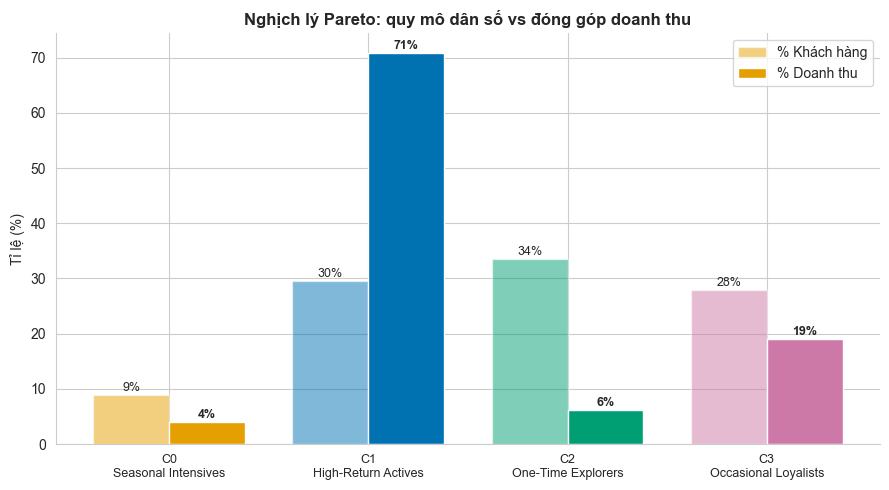

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(CLUSTER_ORDER)); w = 0.38
pop = [(profiles['cluster'] == c).mean() * 100 for c in CLUSTER_ORDER]
rev = [rev_by_cluster[c] / rev_by_cluster.sum() * 100 for c in CLUSTER_ORDER]
colors = [CLUSTER_COLORS[c] for c in CLUSTER_ORDER]

ax.bar(x - w/2, pop, w, label='% Khách hàng', color=colors, alpha=0.5, edgecolor='white')
ax.bar(x + w/2, rev, w, label='% Doanh thu',  color=colors, edgecolor='white')
for i, (p, r) in enumerate(zip(pop, rev)):
    ax.text(i - w/2, p + 0.7, f'{p:.0f}%', ha='center', fontsize=9)
    ax.text(i + w/2, r + 0.7, f'{r:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'C{c}\n{SEGMENT_NAMES[c]}' for c in CLUSTER_ORDER], fontsize=9)
ax.set_ylabel('Tỉ lệ (%)')
ax.set_title('Nghịch lý Pareto: quy mô dân số vs đóng góp doanh thu', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'population_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Vân tay cụm

Trung vị mỗi đặc trưng, chuẩn hoá **z-score theo từng đặc trưng** (giữa 4 cụm) để thấy *cụm nào cao/thấp tương đối*. Màu = độ lệch chuẩn hoá; **số in trên ô = giá trị thực (trung vị)**.


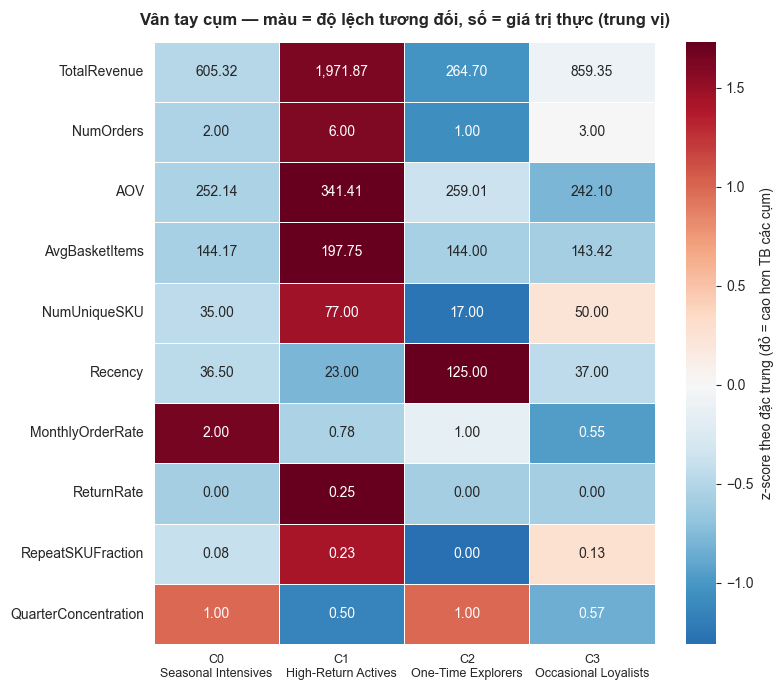

In [6]:
fp_metrics = [
    'TotalRevenue', 'NumOrders', 'AOV', 'AvgBasketItems', 'NumUniqueSKU',
    'Recency', 'MonthlyOrderRate', 'ReturnRate', 'RepeatSKUFraction', 'QuarterConcentration',
]
med = profiles.groupby('cluster')[fp_metrics].median().loc[CLUSTER_ORDER]
z = (med - med.mean()) / med.std(ddof=0)   # z-score theo cột (mỗi đặc trưng)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(z.T, annot=med.T, fmt=',.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'z-score theo đặc trưng (đỏ = cao hơn TB các cụm)'},
            linewidths=.5, linecolor='white', ax=ax)
ax.set_xticklabels([f'C{c}\n{SEGMENT_NAMES[c]}' for c in CLUSTER_ORDER], rotation=0, fontsize=9)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title('Vân tay cụm — màu = độ lệch tương đối, số = giá trị thực (trung vị)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. So sánh 4 chỉ số kinh doanh cốt lõi

LTV, tần suất, recency (trung vị) và tỉ lệ huỷ hoá đơn (**trung bình** — vì ReturnRate lệch mạnh, trung vị bằng 0 ở nhiều cụm).


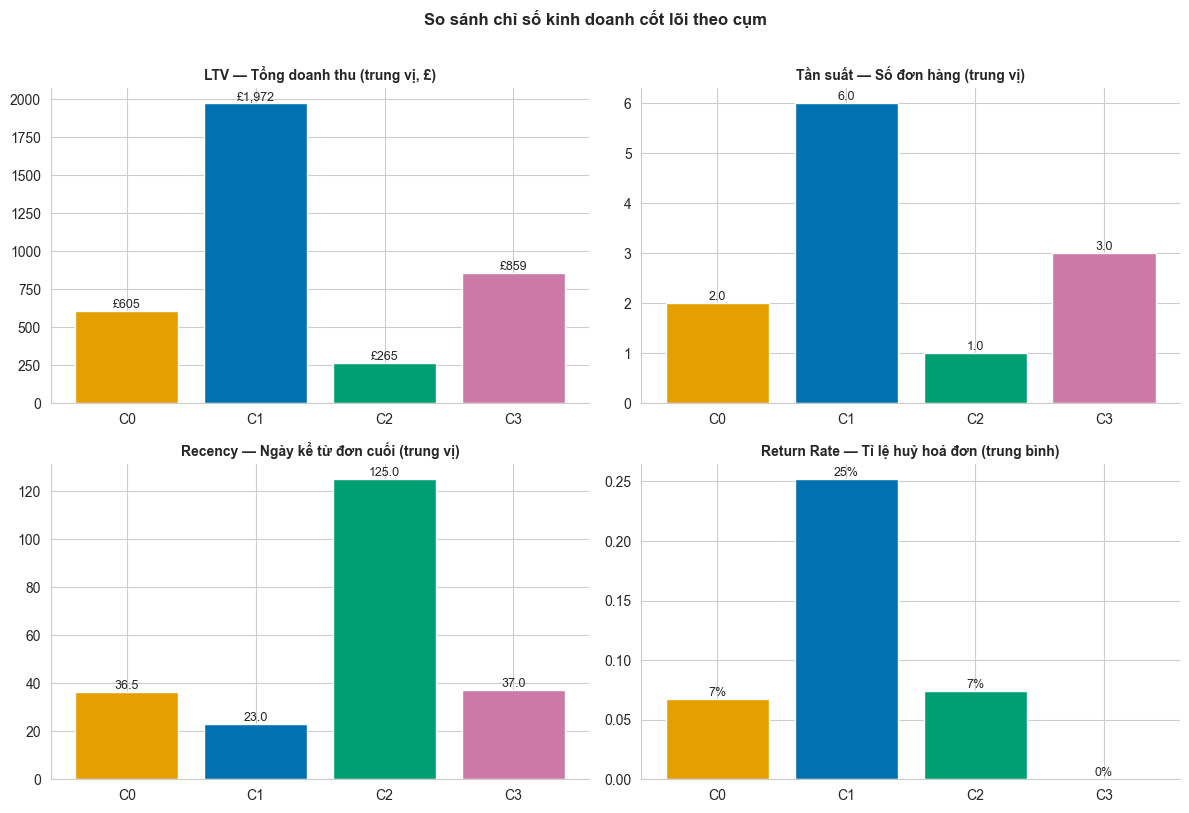

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
panels = [
    ('TotalRevenue', 'LTV — Tổng doanh thu (trung vị, £)',        False),
    ('NumOrders',    'Tần suất — Số đơn hàng (trung vị)',          False),
    ('Recency',      'Recency — Ngày kể từ đơn cuối (trung vị)',   False),
    ('ReturnRate',   'Return Rate — Tỉ lệ huỷ hoá đơn (trung bình)', True),
]
for ax, (metric, title, use_mean) in zip(axes.ravel(), panels):
    vals = (profiles.groupby('cluster')[metric].mean() if use_mean
            else profiles.groupby('cluster')[metric].median()).loc[CLUSTER_ORDER]
    bars = ax.bar([f'C{c}' for c in CLUSTER_ORDER], vals.values,
                  color=[CLUSTER_COLORS[c] for c in CLUSTER_ORDER], edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    for b, v in zip(bars, vals.values):
        lbl = (f'{v:.0%}' if metric == 'ReturnRate'
               else f'£{v:,.0f}' if metric == 'TotalRevenue' else f'{v:,.1f}')
        ax.text(b.get_x() + b.get_width() / 2, v, lbl, ha='center', va='bottom', fontsize=9)

plt.suptitle('So sánh chỉ số kinh doanh cốt lõi theo cụm', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kpi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Lưu kết quả

- `processed/cluster_customer_profiles.csv` — hồ sơ thô từng khách hàng (KPI + đặc trưng + nhãn cụm), dùng cho phân tích / CRM downstream.
- `processed/cluster_strategy_summary.csv` — bảng tóm tắt theo cụm.


In [8]:
prof_out  = profiles.reset_index()
prof_path = wpath('processed/cluster_customer_profiles.csv')
prof_out.to_csv(prof_path, index=False)

summ_path = wpath('processed/cluster_strategy_summary.csv')
summary.to_csv(summ_path)

print('Đã lưu:')
print('  ', prof_path, f'({len(prof_out):,} dòng)')
print('  ', summ_path)

Đã lưu:
   /Users/thaihanguyen/Desktop/03_work/60_AIO2025/03_projects/04_advanced_customer_segmentation/02_source_code/data/_sandbox/processed/cluster_customer_profiles.csv (3,741 dòng)
   /Users/thaihanguyen/Desktop/03_work/60_AIO2025/03_projects/04_advanced_customer_segmentation/02_source_code/data/_sandbox/processed/cluster_strategy_summary.csv


## 8. Chiến lược cho từng cụm

> Rút ra trực tiếp từ bảng hồ sơ ở trên — mỗi khuyến nghị neo vào con số thực.

**Bức tranh Pareto:** `C1` chỉ chiếm **~30% khách hàng** nhưng tạo **~71% doanh thu**. `C2` là **~34% khách hàng** nhưng chỉ **~6% doanh thu**. Ngân sách nên phân bổ theo giá trị, không theo đầu người.

---

### 🟦 C1 · High-Return Actives — *Bảo vệ & giảm hoàn trả* (ưu tiên #1)
**Chân dung:** LTV trung vị **~£1.972** (cao nhất), **6 đơn**/khách, giỏ lớn nhất (**~198 món**), danh mục rộng nhất (**~77 SKU**), recency thấp (**~23 ngày** — đang hoạt động). **Nhưng ReturnRate ~25%** — cứ 4 hoá đơn thì 1 bị huỷ.
**Đây là nhóm tạo ~71% doanh thu → mọi rủi ro rời bỏ ở đây là đắt nhất.**
- **Giảm hoàn trả** = đòn bẩy lợi nhuận lớn nhất: ảnh, bảng size, mô tả sản phẩm chính xác hơn cho các SKU bị huỷ nhiều; rà soát lỗi đóng gói/giao hàng.
- Chương trình **loyalty/VIP tier**, early-access, account manager cho nhóm đầu bảng.
- **Cảnh báo churn**: theo dõi recency; nếu vượt ngưỡng thường lệ → can thiệp ngay.

### 🟪 C3 · Occasional Loyalists — *Nuôi lớn* (ưu tiên #2)
**Chân dung:** LTV **~£859**, **3 đơn**, **ReturnRate ≈ 0** (khách sạch nhất, đáng tin), recency **~37 ngày**, mua rải đều trong năm (QuarterConcentration ~0.57).
**~28% khách → ~19% doanh thu.** Nền tảng ổn định, biên lợi nhuận tốt (không tốn chi phí hoàn trả).
- **Tăng tần suất**: email nhịp đều, gợi ý bổ sung, cross-sell dựa trên lịch sử.
- **Lộ trình nâng hạng lên C1**: khuyến khích mở rộng danh mục và giá trị đơn; đây là nguồn khách VIP tương lai rẻ nhất.
- Chi phí giữ chân thấp — duy trì trải nghiệm nhất quán.

### 🟧 C0 · Seasonal Intensives — *Kéo dài vòng đời* (thị trường ngách)
**Chân dung:** MonthlyOrderRate cao (**~2 đơn/tháng**) nhưng **QuarterConcentration = 1.0** — dồn toàn bộ chi tiêu vào **một quý** rồi biến mất; LTV **~£605**, chỉ **~4% doanh thu**, **8.8% khách**.
- **Đón đầu mùa vụ**: xác định quý cao điểm của họ, gửi chiến dịch trước thời điểm đó.
- **Phá vỡ tính mùa vụ**: ưu đãi trái mùa, sản phẩm bổ trợ để tạo đơn hàng ngoài mùa cao điểm.
- Kỳ vọng có kiểm soát: nhóm nhỏ, đừng đầu tư quá mức — mục tiêu là thêm 1–2 đơn ngoài mùa.

### 🟩 C2 · One-Time Explorers — *Kích hoạt lần mua thứ 2* (số đông, giá trị thấp)
**Chân dung:** **1 đơn duy nhất**, recency **~125 ngày** (phần lớn đã ngủ đông), LTV thấp nhất **~£265**, ít SKU (**~17**), QuarterConcentration = 1.0.
**~34% khách nhưng chỉ ~6% doanh thu — quỹ đạo hoặc là chuyển đổi, hoặc là rời bỏ.**
- **Chiến dịch mua-lần-2**: cửa sổ vàng ngay sau đơn đầu; ưu đãi có thời hạn, freeship cho đơn kế tiếp.
- **Onboarding**: email chào mừng, gợi ý sản phẩm liên quan đơn đầu.
- **Hiệu quả chi phí**: đa số đã lạnh (recency ~125 ngày) → dùng kênh rẻ (email/retargeting tự động), tránh ưu đãi sâu đại trà. Coi đây là bài toán chuyển đổi tỉ lệ nhỏ trên số đông.

---

**Tóm tắt phân bổ nguồn lực:**

| Cụm | Vai trò | Hành động chính | Ưu tiên |
|-----|---------|-----------------|:-------:|
| **C1** High-Return Actives | Động cơ doanh thu (71%) | Giảm hoàn trả + giữ chân VIP | 🔴 Cao nhất |
| **C3** Occasional Loyalists | Nền tảng ổn định | Tăng tần suất, nâng hạng lên C1 | 🟠 Cao |
| **C0** Seasonal Intensives | Ngách mùa vụ | Kéo dài ngoài mùa cao điểm | 🟡 Vừa |
| **C2** One-Time Explorers | Phễu số đông | Kích hoạt đơn thứ 2 (kênh rẻ) | 🟢 Chọn lọc |
